## Importing libraries and reading the dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn import preprocessing
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

In [2]:
e_data = pd.read_csv('employee_census_previous_closure.csv')
elyon_data = pd.read_csv('employee_census_lyon.csv')

## Understanding the data

In [3]:
# checking for null columns
print('`nan` values: ' + str(np.sum(e_data.isna().sum())))
print('observation size: ' + str(len(e_data)))

`nan` values: 268
observation size: 1029


In [4]:
# Creating a new dataframe of columns with `nan` values to understand them for data imputation
null_cols = e_data.loc[:, e_data.isnull().any()]
null_cols.isna().sum()
#null_cols.dtypes

Age                 136
BusinessTravel        5
DailyRate            27
DistanceFromHome     95
MaritalStatus         5
dtype: int64

Text(0.5, 1.0, 'Distribution of Numerical Variables')

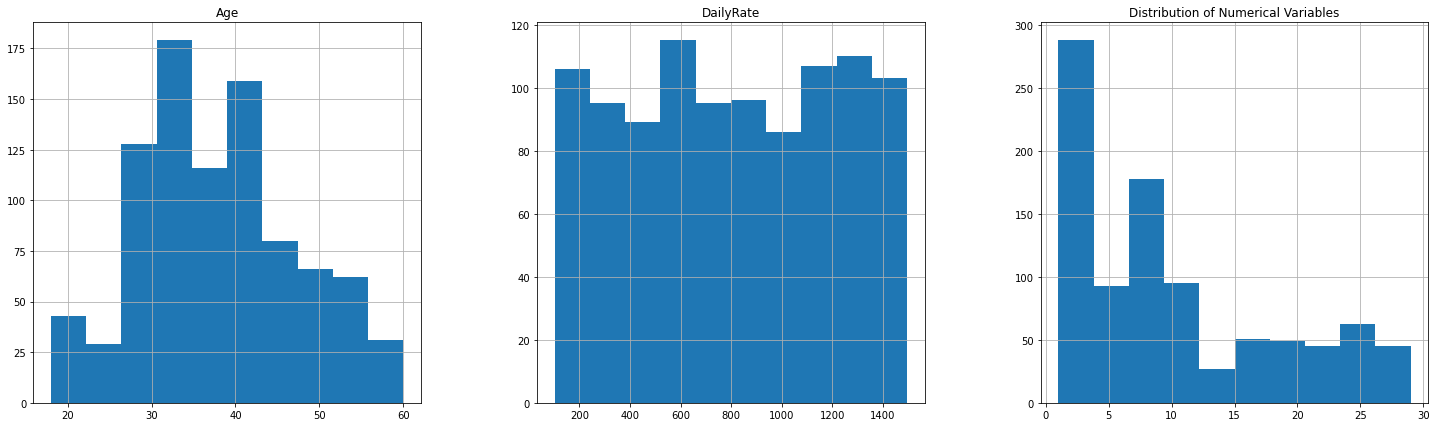

In [5]:
# visualising the distribution of numeriacal variables with `nan` values
fig = plt.figure(figsize=(25,7))
ax1 = fig.add_subplot(1,3,1)
null_cols.hist('Age', ax=ax1)
ax2 = fig.add_subplot(1,3,2)
null_cols.hist('DailyRate', ax=ax2)
ax3 = fig.add_subplot(1,3,3)
null_cols.hist('DistanceFromHome', ax=ax3)
plt.title("Distribution of Numerical Variables")

### Data Cleaning

It can be seen that Age of the employees is close a normal distribution, this is why we can use the mean to impute the `nan` values. </br>
The Daily Rate of the employees appears to have a uniform distribution, allowing for the use of the imputation of the `nan` values. </br>
The Distance From Home of the office has a right-skewed distribution, therefore using the median of the distribution is more appropriate for data imputation than using the mean.

In [6]:
# imputation of the numerical variables
e_data['Age'].fillna(e_data['Age'].mean(), inplace=True)
e_data['DailyRate'].fillna(e_data['DailyRate'].mean(), inplace=True)
e_data['DistanceFromHome'].fillna(e_data['DistanceFromHome'].median(), inplace=True)

The `nan` values for the categorical variables will be imputed as dummy variables along with the rest of the categotical variables. This is because there are quite a few `nan` values for these variables in the test dataset as well and therefore doing this imporve the prediction quality pof the model for those values.

In [7]:
e_data.fillna({'MaritalStatus': 'Not available'}, inplace=True)
e_data.fillna({'BusinessTravel': 'Not available'}, inplace=True)

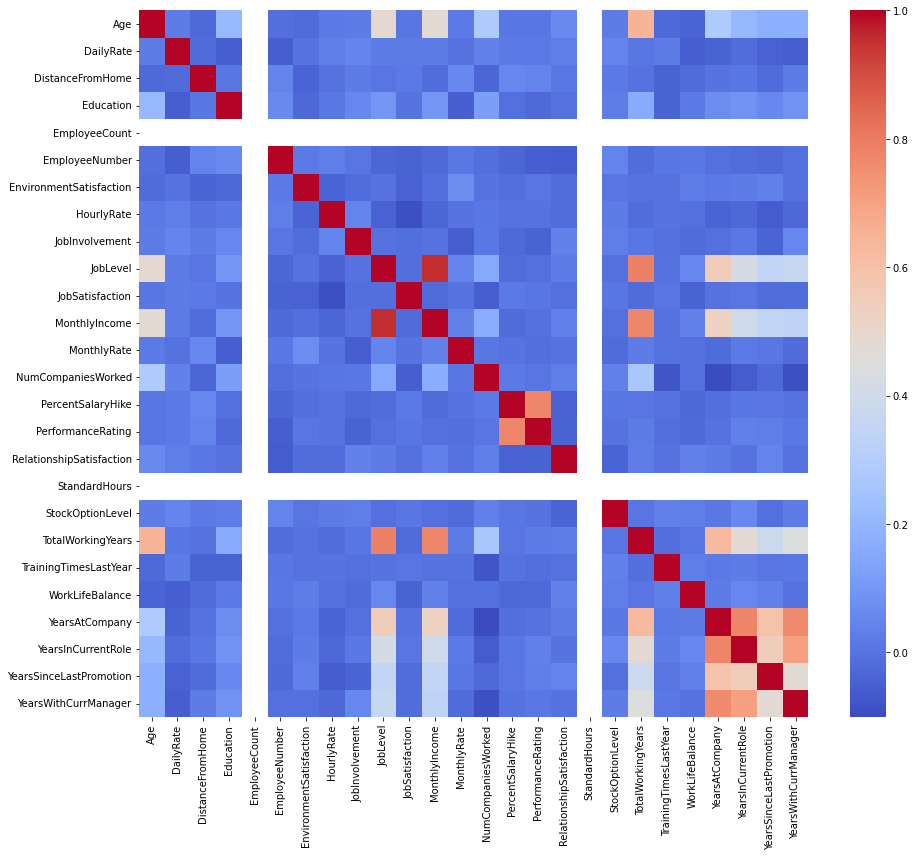

In [8]:
# Plotting a correlation matrix to detect trends of collinearity in the data
# This will indicate if it is necessary to eliminate certain variables as collinearity between dependent variables will affect the qualiy of the regression model

cor_data = e_data.drop(columns=['Attrition'])
corrMatrix = cor_data.corr()
f, ax = plt.subplots(figsize=(15, 13))
ax = sns.heatmap(corrMatrix, cmap='coolwarm')
plt.show()

In [9]:
for col in e_data.columns:
    if e_data[col].dtype == 'object':
        e_data = pd.get_dummies(data=e_data, columns=[col])

e_data.drop(['Attrition_No', 'EmployeeNumber', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsSinceLastPromotion', 'JobRole_Human Resources', 'JobLevel'], axis=1, inplace=True)
e_data.rename(columns={"Attrition_Yes": "Attrition"}, inplace=True)

## Prediction of the accdeptance of the RCC using a regression model

In [10]:
Y = e_data["Attrition"]
X = e_data.drop(columns = ["Attrition"])

In [11]:
trainX, validX, trainY, validY = train_test_split(X, Y, test_size=0.4, random_state=357)

In [12]:
classifier_LR = LogisticRegression(max_iter=2000)
classifier_LR.fit(trainX, trainY.values.ravel())

/Users/yashvajani/opt/anaconda3/envs/dtvc/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=2000)

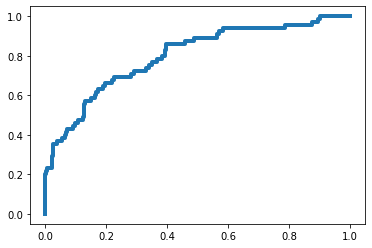

In [13]:
Y_pred_probs = classifier_LR.predict_proba(validX)[:, 1]
fpr, tpr, thresholds = metrics.roc_curve(validY, Y_pred_probs)
plt.plot(fpr, tpr, linewidth=4)
plt.show()

In [14]:
coefficients = pd.DataFrame(data=list(X.columns), columns=['Variables'])
coefficients['Coefficient'] = classifier_LR.coef_[0]
coefficients.sort_values(by=['Coefficient'], ascending=False)

,Variables,Coefficient
50,OverTime_Yes,0.826524
47,MaritalStatus_Single,0.374712
23,BusinessTravel_Travel_Frequently,0.368610
27,Department_Sales,0.314874
43,JobRole_Sales Representative,0.258012
33,EducationField_Technical Degree,0.220497
35,Gender_Male,0.201526
11,NumCompaniesWorked,0.197865
37,JobRole_Laboratory Technician,0.188452
30,EducationField_Marketing,0.163375


## Lyon Dataset

In [15]:
print('`nan` values: ' + str(np.sum(elyon_data.isna().sum())))
print('observation size: ' + str(len(elyon_data)))

`nan` values: 131
observation size: 441


In [16]:
null_cols_lyon = elyon_data.loc[:, elyon_data.isnull().any()]
null_cols_lyon.isna().sum()
#null_cols_lyon.dtypes

Age                 55
BusinessTravel       5
DailyRate           14
DistanceFromHome    54
MaritalStatus        3
dtype: int64

Text(0.5, 1.0, 'Distribution of Numerical Variables in Lyon')

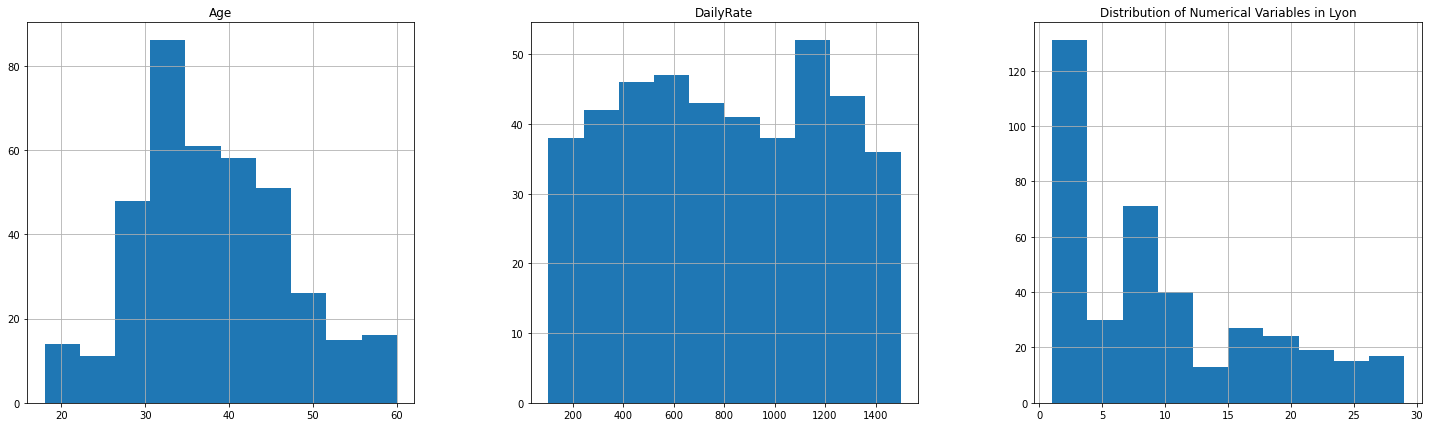

In [17]:
# visualising the distribution of numeriacal variables with `nan` values for employees in Lyon
fig = plt.figure(figsize=(25,7))
ax1 = fig.add_subplot(1,3,1)
null_cols_lyon.hist('Age', ax=ax1)
ax2 = fig.add_subplot(1,3,2)
null_cols_lyon.hist('DailyRate', ax=ax2)
ax3 = fig.add_subplot(1,3,3)
null_cols_lyon.hist('DistanceFromHome', ax=ax3)
plt.title("Distribution of Numerical Variables in Lyon")

### Cleaning the Lyon Dataset

In [18]:
# imputation of the numerical variables for the employees in Lyon
elyon_data['Age'].fillna(elyon_data['Age'].mean(), inplace=True)
elyon_data['DailyRate'].fillna(elyon_data['DailyRate'].mean(), inplace=True)
elyon_data['DistanceFromHome'].fillna(elyon_data['DistanceFromHome'].median(), inplace=True)

In [19]:
elyon_data.fillna({'MaritalStatus': 'Not available'}, inplace=True)
elyon_data.fillna({'BusinessTravel': 'Not available'}, inplace=True)

In [20]:
for col in elyon_data.columns:
    if elyon_data[col].dtype == 'object':
        elyon_data = pd.get_dummies(data=elyon_data, columns=[col])

prob_df = pd.DataFrame(elyon_data['EmployeeNumber'])
elyon_data.drop(['EmployeeNumber', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsSinceLastPromotion', 'JobRole_Human Resources', 'JobLevel'], axis=1, inplace=True)
elyon_data.rename(columns={"Attrition_Yes": "Attrition"}, inplace=True)

### Regression on the Lyon Dataset

In [21]:
testX = elyon_data

In [22]:
Y_pred = classifier_LR.predict_proba(testX)[:, 1]

In [23]:
Probabilities = pd.DataFrame(Y_pred, columns=['Porbability'])

In [24]:
Probabilities

,Porbability
0,0.062064
1,0.005839
2,0.321436
3,0.030233
4,0.089088
...,...
436,0.081605
437,0.211471
438,0.570194
439,0.012942
